In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"C:\Users\kumar\Downloads\archive (6)\student_exam_data_new.csv")

In [3]:
df['Previous Exam Score']=round(df['Previous Exam Score'],1)

In [4]:
df.head()

,Study Hours,Previous Exam Score,Pass/Fail
0,4.370861,81.9,0
1,9.556429,72.2,1
2,7.587945,58.6,0
3,6.387926,88.8,1
4,2.404168,81.1,0


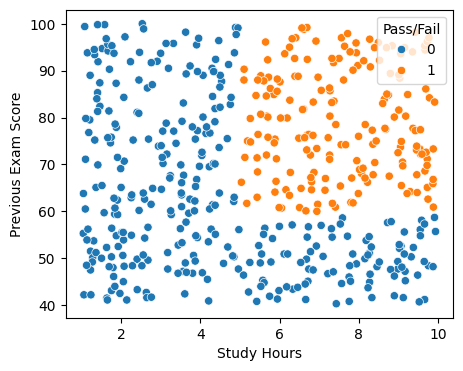

In [5]:
plt.figure(figsize=[5,4])
sns.scatterplot(x='Study Hours',y='Previous Exam Score',data=df,hue='Pass/Fail')
plt.show()

# check data imblanced as percentage

In [6]:
pd.Series(df['Pass/Fail']).value_counts(normalize=True)*100


Pass/Fail
0    63.2
1    36.8
Name: proportion, dtype: float64

In [7]:
df['Pass/Fail'].value_counts()

Pass/Fail
0    316
1    184
Name: count, dtype: int64

# train model using logisticregression

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,f1_score,recall_score
lg=LogisticRegression()
x=df[['Study Hours','Previous Exam Score']]
y=df['Pass/Fail']
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.2,random_state=42)
lg.fit(x_train,y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [9]:
lg.score(x_test,y_test)*100

87.5

In [10]:
result=lg.predict(x_test)

In [11]:
cm=confusion_matrix(y_test,result)

In [12]:
cm

array([[233,  20],
       [ 30, 117]])

<Axes: >

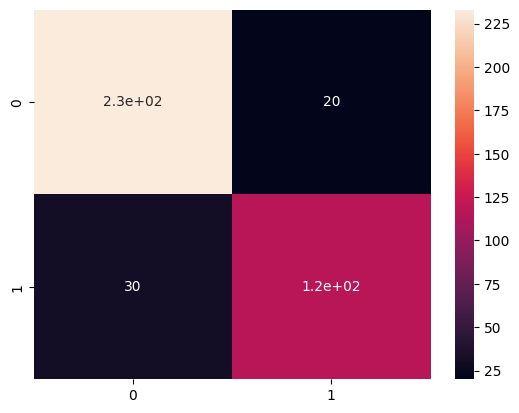

In [13]:
sns.heatmap(cm,annot=True)

In [14]:
x_test,y_test

(     Study Hours  Previous Exam Score
 361     6.789594                 67.2
 73      8.339153                 77.3
 374     1.640698                 41.5
 155     3.178497                 47.7
 104     9.168098                 47.2
 ..           ...                  ...
 434     1.756961                 50.3
 430     2.286925                 48.4
 337     7.332921                 61.7
 236     3.526951                 63.5
 207     6.971516                 88.6
 
 [400 rows x 2 columns],
 361    1
 73     1
 374    0
 155    0
 104    0
       ..
 434    0
 430    0
 337    1
 236    0
 207    1
 Name: Pass/Fail, Length: 400, dtype: int64)

In [15]:
df.head()

,Study Hours,Previous Exam Score,Pass/Fail
0,4.370861,81.9,0
1,9.556429,72.2,1
2,7.587945,58.6,0
3,6.387926,88.8,1
4,2.404168,81.1,0


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Study Hours          500 non-null    float64
 1   Previous Exam Score  500 non-null    float64
 2   Pass/Fail            500 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 11.8 KB


In [17]:
df.describe()

,Study Hours,Previous Exam Score,Pass/Fail
count,500.000000,500.000000,500.000000
mean,5.487055,68.915000,0.368000
std,2.688196,17.129577,0.482744
min,1.045554,40.300000,0.000000
25%,3.171517,53.775000,0.000000
50%,5.618474,68.300000,0.000000
75%,7.805124,83.550000,1.000000
max,9.936683,100.000000,1.000000


# handeling imbalanced data

In [18]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler
ru=RandomUnderSampler()
ru_x,ru_y=ru.fit_resample(x,y)




In [19]:
ru_y.value_counts()

Pass/Fail
0    184
1    184
Name: count, dtype: int64

In [20]:
x_train,x_test,y_train,y_test=train_test_split(ru_x,ru_y,test_size=0.2,random_state=42)

In [21]:
lg.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [22]:
res=lg.predict(x_test)

In [23]:
print(accuracy_score(y_test,res))
print(recall_score(y_test,res))
print(f1_score(y_test,res))
print(precision_score(y_test,res))


0.8648648648648649
0.9117647058823529
0.8611111111111112
0.8157894736842105


print(accuracy_score(y_test,result)*100)
print(precision_score(y_test,result)*100)
print(f1_score(y_test,result)*100)
print(recall_score(y_test,result)*100)
87.5
85.40145985401459
82.3943661971831
79.5918367346938

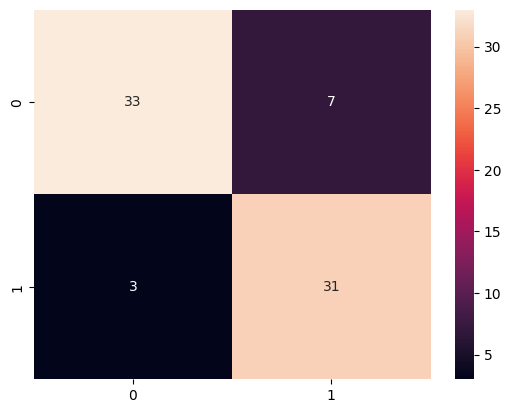

In [24]:
sns.heatmap(confusion_matrix(y_test,res),annot=True)
plt.show()

In [25]:
x_test,y_test

(     Study Hours  Previous Exam Score
 215     3.135242                 95.8
 230     8.153302                 49.9
 424     1.518029                 65.5
 336     8.699145                 94.9
 460     2.057736                 45.0
 ..           ...                  ...
 493     2.693090                 75.4
 378     8.330216                 41.6
 24      5.104630                 90.3
 326     5.989186                 60.8
 302     5.865716                 74.6
 
 [74 rows x 2 columns],
 215    0
 230    0
 424    0
 336    1
 460    0
       ..
 493    0
 378    0
 24     1
 326    1
 302    1
 Name: Pass/Fail, Length: 74, dtype: int64)

In [26]:
lg.predict([[4.843970,62.1]])

c:\Users\kumar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([0])

In [27]:
ro=RandomOverSampler()
ro_x,ro_y=ro.fit_resample(x,y)


In [28]:
x_train,x_test,y_train,y_test=train_test_split(ro_x,ro_y,test_size=0.2,random_state=42)

In [29]:
x_train

,Study Hours,Previous Exam Score
6,1.522753,94.7
104,9.168098,47.2
114,6.700634,92.4
493,2.693090,75.4
414,6.686535,73.1
...,...,...
71,2.788441,87.0
106,4.693446,52.4
270,8.284250,46.6
435,7.308722,56.3


In [30]:
lg.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [31]:
ress=lg.predict(x_test)

In [32]:
lg.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [33]:
print(accuracy_score(y_test,ress))
print(recall_score(y_test,ress))
print(f1_score(y_test,ress))
print(precision_score(y_test,ress))


0.84251968503937
0.8225806451612904
0.8360655737704918
0.85


In [34]:
y.value_counts()

Pass/Fail
0    316
1    184
Name: count, dtype: int64

In [35]:
ro_y.value_counts()

Pass/Fail
0    316
1    316
Name: count, dtype: int64

# naive bayes algorithm

##1-gaussian NB(if the nature of the data set is in normal distribution )
  2-bournoulli Nb(having all value in 0,1) onehot encodding 
  3-multinomial NB(used in textual data)
  TO CHECK NORMAL DISTRIBUTION WE NEED TO DRAW KD PLOT

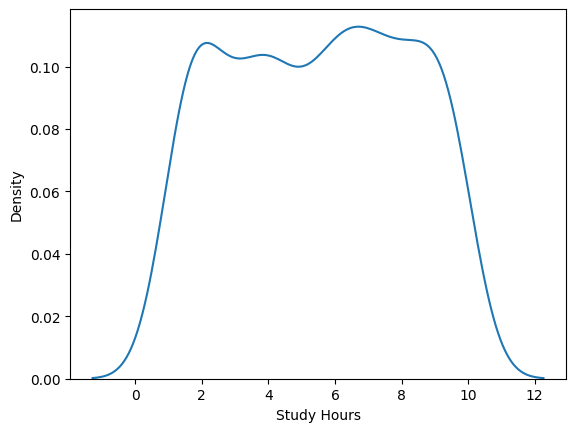

In [36]:
sns.kdeplot(data=df['Study Hours'])
plt.show()

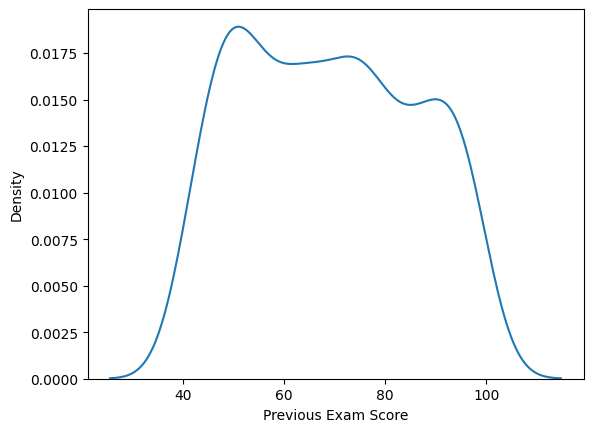

In [37]:
sns.kdeplot(data=df['Previous Exam Score'])
plt.show()


In [38]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [39]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB

In [40]:
gnb=GaussianNB()
gnb.fit(x_train,y_train)

,priors,None
,var_smoothing,1e-09


In [41]:
gnb.score(x_train,y_train),gnb.score(x_test,y_test)

(0.936, 0.928)

In [42]:
mnb=MultinomialNB()
mnb.fit(x_train,y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [43]:
mnb.score(x_train,y_train),mnb.score(x_test,y_test)

(0.608, 0.592)

In [44]:
bnb=BernoulliNB()
bnb.fit(x_train,y_train)

,alpha,1.0
,force_alpha,True
,binarize,0.0
,fit_prior,True
,class_prior,None


In [45]:
bnb.score(x_train,y_train),bnb.score(x_train,y_train)

(0.632, 0.632)

In [46]:
from mlxtend.plotting import plot_decision_regions


c:\Users\kumar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


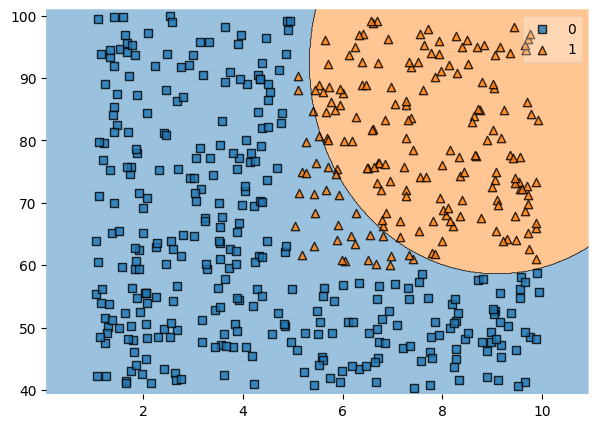

In [47]:
plt.figure(figsize=[7,5])
plot_decision_regions(x.to_numpy(),y.to_numpy(),clf=gnb)
plt.show()

c:\Users\kumar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MultinomialNB was fitted with feature names
  warnings.warn(


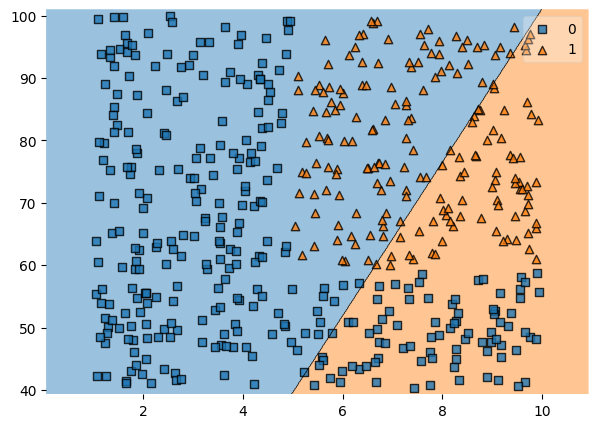

In [48]:
plt.figure(figsize=[7,5])
plot_decision_regions(x.to_numpy(),y.to_numpy(),clf=mnb)
plt.show()

c:\Users\kumar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but BernoulliNB was fitted with feature names
  warnings.warn(


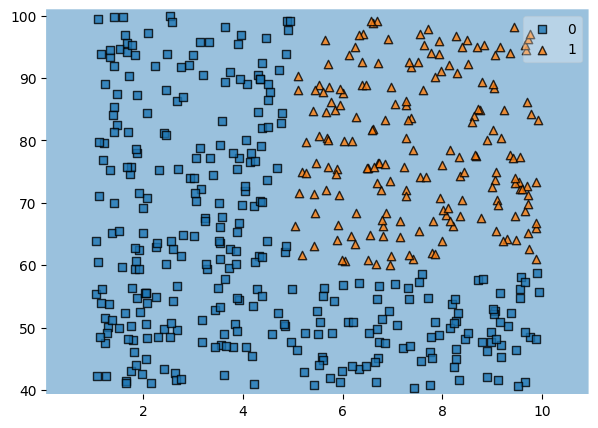

In [49]:
plt.figure(figsize=[7,5])
plot_decision_regions(x.to_numpy(),y.to_numpy(),clf=bnb)
plt.show()

In [50]:
data=pd.read_csv(r"C:\Users\kumar\Downloads\personality_dataset (1).csv")

In [51]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Time_spent_Alone           5000 non-null   int64 
 1   Stage_fear                 5000 non-null   object
 2   Social_event_attendance    5000 non-null   int64 
 3   Going_outside              5000 non-null   int64 
 4   Drained_after_socializing  5000 non-null   object
 5   Friends_circle_size        5000 non-null   int64 
 6   Post_frequency             5000 non-null   int64 
 7   Personality                5000 non-null   object
dtypes: int64(5), object(3)
memory usage: 312.6+ KB


In [52]:
data.describe()

,Time_spent_Alone,Social_event_attendance,Going_outside,Friends_circle_size,Post_frequency
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,4.969000,4.995200,3.523400,7.253200,4.759800
std,3.033922,2.862449,2.088618,4.045783,2.780369
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,3.000000,2.000000,5.000000,3.000000
50%,5.000000,5.000000,4.000000,7.000000,5.000000
75%,7.000000,7.000000,5.000000,10.000000,7.000000
max,11.000000,10.000000,7.000000,15.000000,10.000000


In [53]:
data1=data.copy()

In [54]:
from sklearn.preprocessing import LabelEncoder
lb=LabelEncoder()
data1['Stage_fear']=pd.DataFrame(lb.fit_transform(data1['Stage_fear']))
data1['Drained_after_socializing']=pd.DataFrame(lb.fit_transform(data1['Drained_after_socializing']))
data1['Personality']=pd.DataFrame(lb.fit_transform(data1['Personality']))

In [55]:
data1['Personality'].value_counts()

Personality
1    2502
0    2498
Name: count, dtype: int64

In [56]:
data.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,3,Yes,6,7,No,14,5,Extrovert
1,2,No,8,6,No,7,8,Extrovert
2,1,No,9,4,No,9,3,Extrovert
3,8,No,0,0,Yes,9,3,Introvert
4,5,Yes,3,0,No,2,6,Introvert


In [57]:
data1.head(10)

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,3,1,6,7,0,14,5,0
1,2,0,8,6,0,7,8,0
2,1,0,9,4,0,9,3,0
3,8,0,0,0,1,9,3,1
4,5,1,3,0,0,2,6,1
5,0,0,7,3,1,6,4,0
6,1,0,7,6,0,11,6,0
7,6,0,4,6,0,8,4,0
8,8,0,3,4,1,9,3,1
9,6,1,6,3,0,7,4,1


<Axes: xlabel='Time_spent_Alone', ylabel='Personality'>

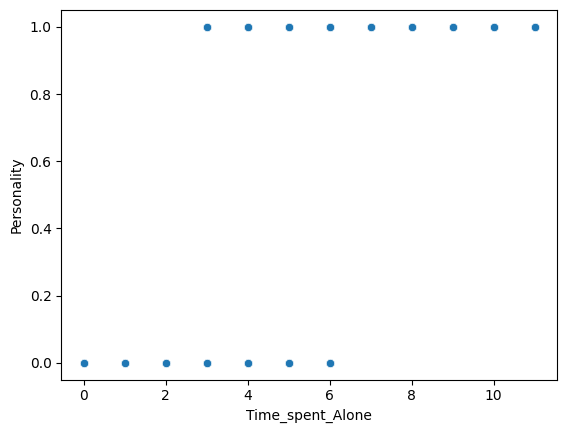

In [58]:
sns.scatterplot(x='Time_spent_Alone',y='Personality',data=data1)

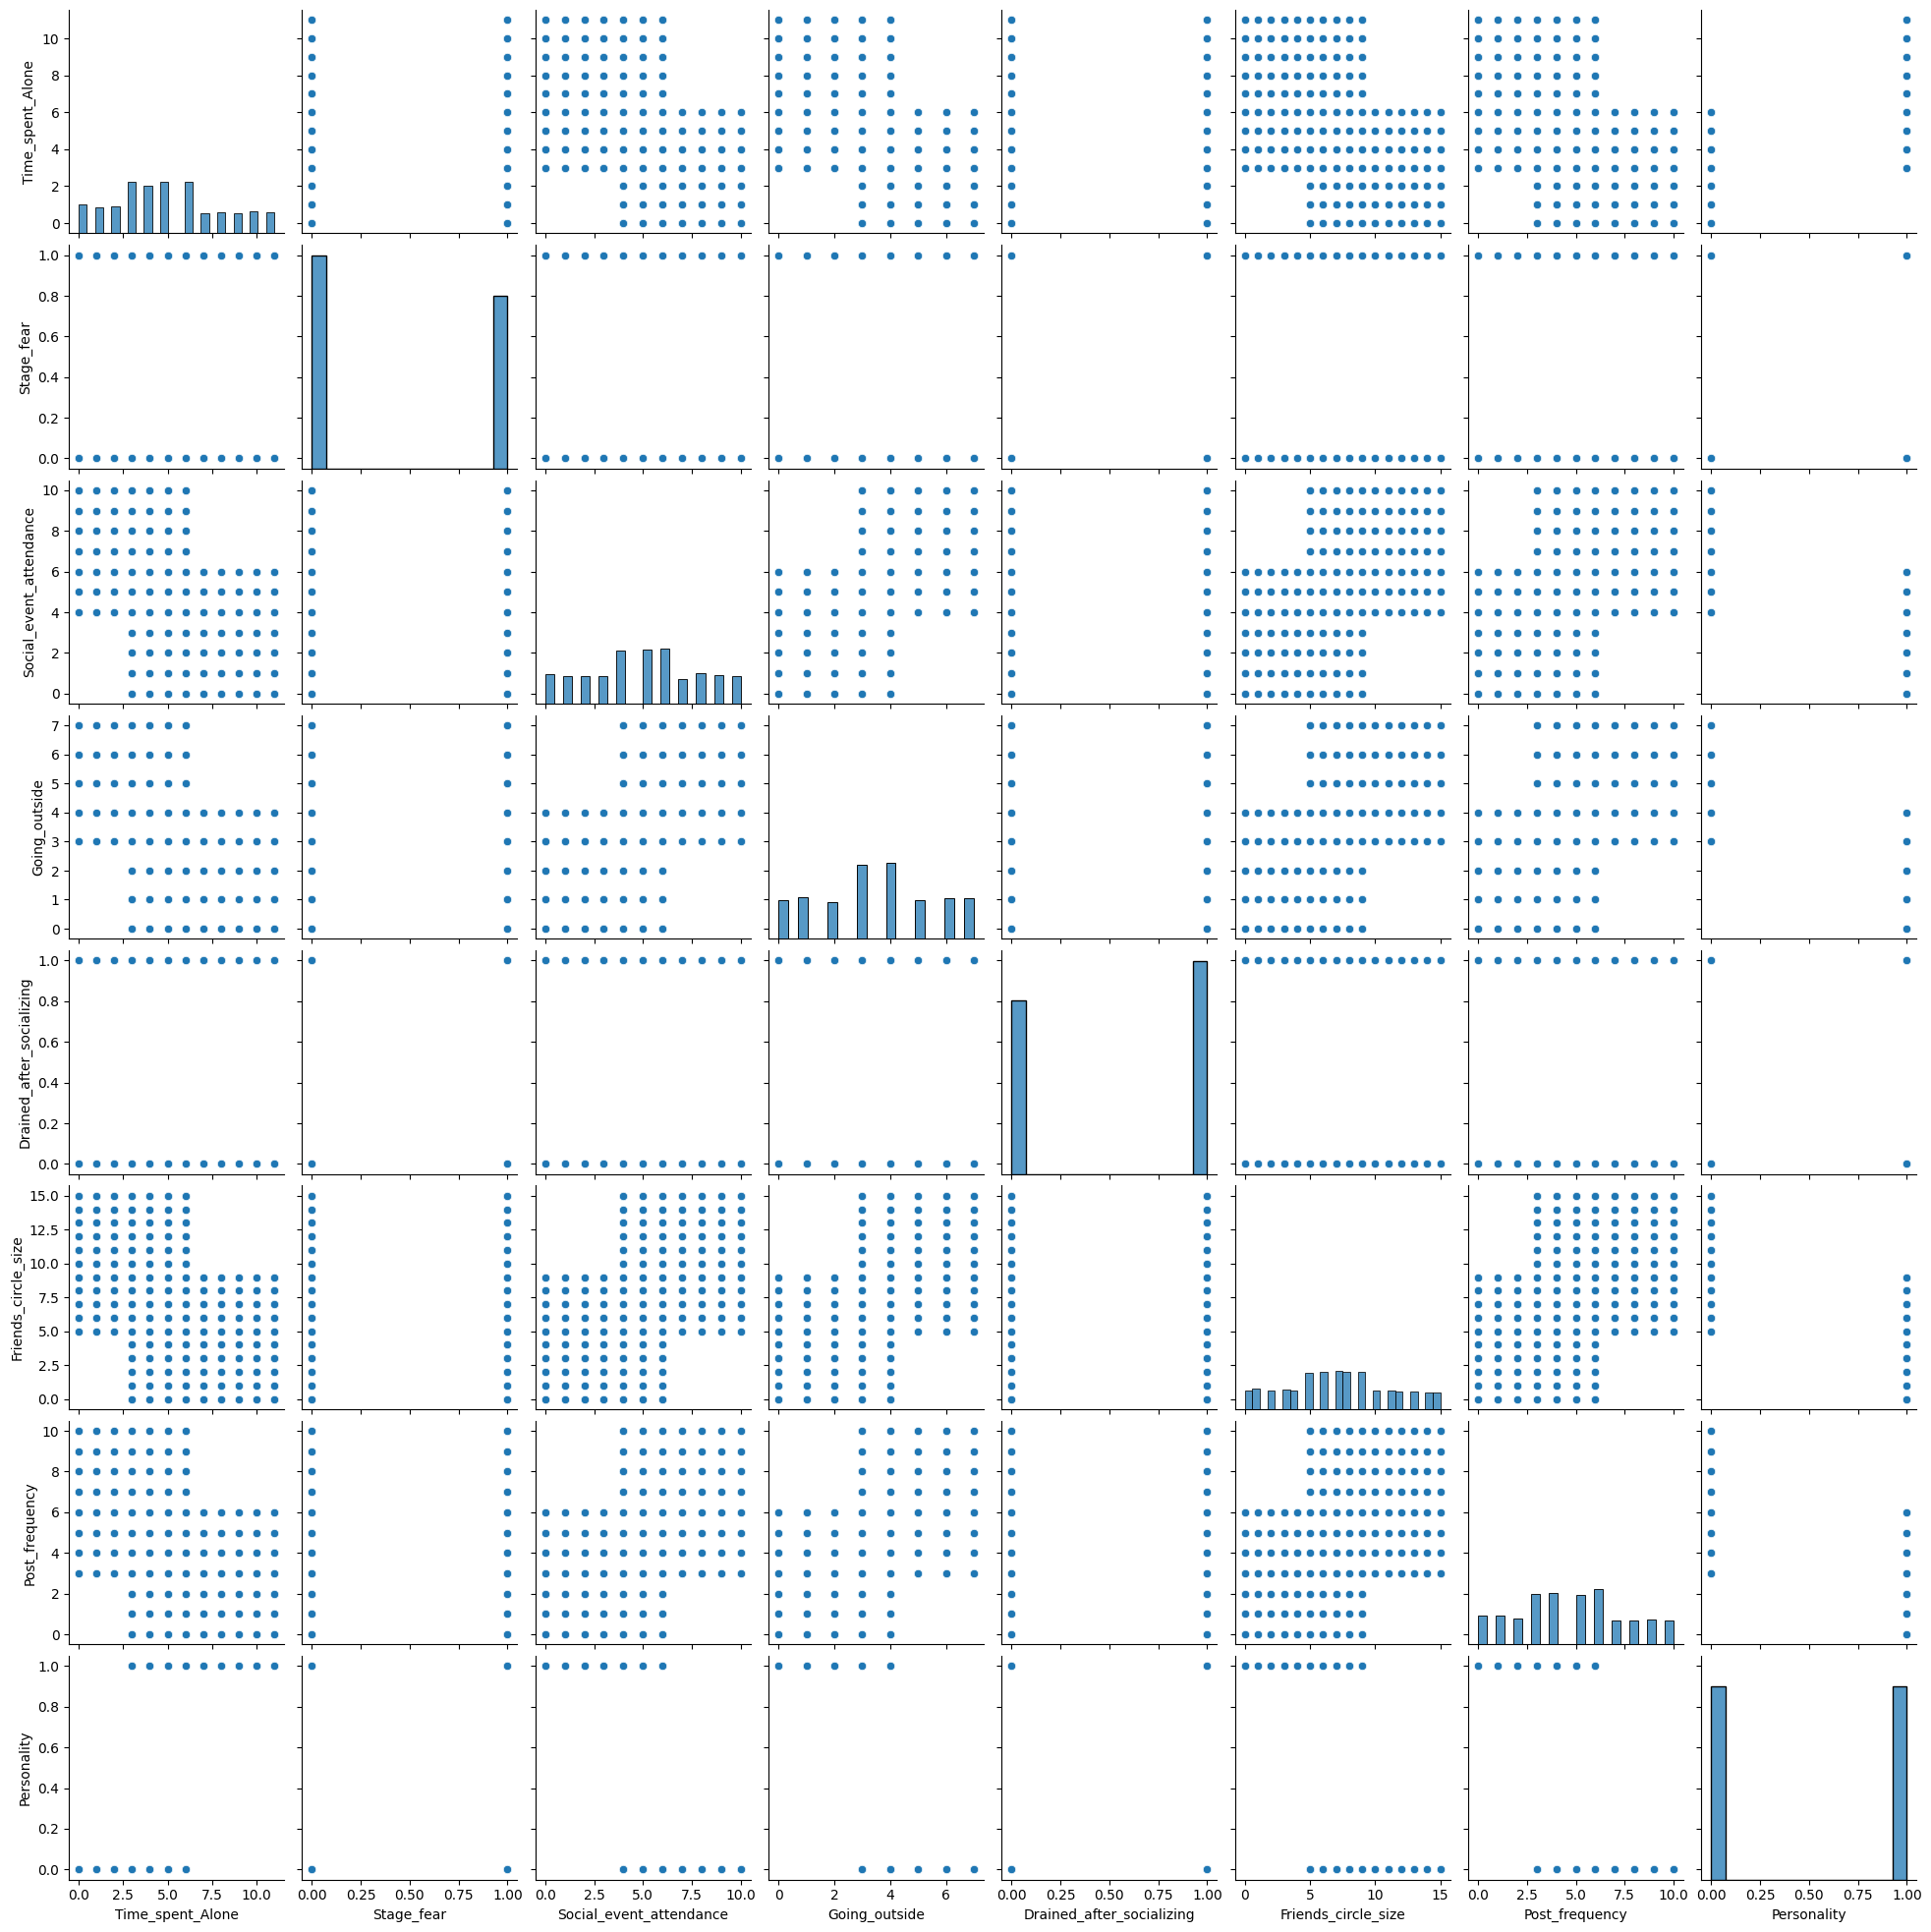

In [59]:
sns.pairplot(data1)
plt.show()

In [60]:
data1.columns

Index(['Time_spent_Alone', 'Stage_fear', 'Social_event_attendance',
       'Going_outside', 'Drained_after_socializing', 'Friends_circle_size',
       'Post_frequency', 'Personality'],
      dtype='object')

In [61]:
x=data1[['Social_event_attendance','Going_outside','Friends_circle_size','Post_frequency']]
y=data1['Personality']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [62]:
from sklearn.naive_bayes import GaussianNB,BernoulliNB,MultinomialNB
from sklearn.linear_model import LogisticRegression
mt=GaussianNB()
lg=LogisticRegression()
mt.fit(x_train,y_train)

,priors,None
,var_smoothing,1e-09


In [69]:
mt.score(x_test,y_test)*100,mt.score(x_train,y_train)*100

(98.1, 97.32499999999999)

In [64]:
x_test

,Social_event_attendance,Going_outside,Friends_circle_size,Post_frequency
1501,6,4,11,10
2586,6,5,14,5
2653,4,0,1,5
1055,6,4,14,6
705,8,5,10,6
...,...,...,...,...
4711,5,5,6,5
2313,7,4,12,8
3214,5,1,7,6
2732,7,3,10,5


In [65]:
y_test

1501    0
2586    0
2653    1
1055    0
705     0
       ..
4711    0
2313    0
3214    1
2732    0
1926    0
Name: Personality, Length: 1000, dtype: int64

In [66]:
def get_int(prompt):
    while True:
        try:
            return int(input(prompt))
        except ValueError:
            print("❌ Please enter a valid number!\n")

a = get_int("Enter value 1: ")
b = get_int("Enter value 2: ")
c = get_int("Enter value 3: ")
d = get_int("Enter value 4: ")
result=mt.predict([[a,b,c,d]])
if(result==1):
    print("he is a introvert")
else:
    print("he is a extrovert")




he is a extrovert


c:\Users\kumar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


In [67]:
result=mt.predict([[a,b,c,d]])
if(result==1):
    print("introvert")
else:
    print("extrovert")


extrovert


c:\Users\kumar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


In [68]:
#plot_decision_regions(x.to_numpy(),y.to_numpy(),clf=mt)
plt.show()